# Cuadratura Gaussiana

Uno de los métodos más poderosos para evaluar integrales de forma numérica es la **cuadratura Gaussiana**.




La idea principal está dada por
\begin{align}
\int_a^b {\rm{d}}x f(x) \approx \sum_{k=1}^{N} w_k f(x_k).
\end{align}
donde:
  * $w_k$ son los "pesos"
  * $x_k$ son los puntos de muestreo
  
Para las ecuaciones de Newton-Cotes de la clase anterior:  
  * Los puntos de muestreo son **equidistantes**.
  * Una ecuación de Newton-Cotes de orden $N$ es *exacta* (i.e., no hay aproximación) para un polinomio de grado $N$.
  * Un polinomio de orden $N$ aproxima una función bien comportada mejor que un polinomio de orden $N-1$, debido al grado de libertad añadido.
  
Por el otro lado, para la cuadratura Gaussiana:
  * Los puntos de muestreo se escogen de manera tal que **no son equidistantes**. Esto introduce más grados de libertad para la misma discretización en $N$ subregiones.
  * Es exacta para un polinomio de orden $(2N - 1)$.
  * Es decir, la cuadratura Gaussiana da la misma precisión que un polinomio de orden $(2N - 1)$.

**Regla universal para escoger $w_k$ y $x_k$**. Los pesos y puntos de muestreo se eligen tal que:
  * $x_k$ corresponden a las $N$ raíces (ceros) de los polinomios de Legendre $P_N(x)$ de orden $N$.
  * Los pesos se eligen tal que:
      - $\displaystyle w_k = \left[\frac{2}{1-x^2}\left(\frac{dP_N}{dx}\right)^{-2}\right]_{x={x_k}}$, con $x_k$ que cumple $P_N(x_k)=0$

Hablemos de los pros y los contras del uso de cuadraturas Gaussianas para evaluar integrales.

* Pros:
  - La ecuación para evaluar los errores es muy complicada. Sin embargo, la aproximación mejora con un error que decrece por un factor ${\rm{const.}} / N^2$ cuando se incrementa el número de subregiones de discretización en uno.
  - Ejemplo: Pasar de $N=10$ a $N=11$, mejora el resultado de la estimación por un factor de $\approx 100$. Esto indica que la convergencia ocurre con muy pocos puntos de muestreo.
  
* Cons:
  - Sólo funciona bien su la función a integrar es relativamente bien comportada. Si no lo es, se requiren más puntos de muestreo cerca de las regiones problemáticas.
  - Es muy complicado evaluar el error de manera precisa si lo necesitamos.

## Polinomios de Legendre

Los polinomios de Legendre son un sistema de polinomios ortogonales que pueden ser definidos de manera recursiva. Tenemos:
\begin{align}
\forall (M, N) \in\mathbb N^2, \quad \int_{-1}^1 {\rm{d}}x P_N(x)P_M(x) = \frac{2\delta_{MN}}{2N+1}.
\end{align}
Note que los polinomios están definidos en el intervalo $[-1, 1]$.
Los se definen empezando con
\begin{align}
P_0(x) = 1 \Rightarrow P_1(x) = x,
\end{align}
tal que los siguientes órdenes se generan con la regla de recursividad
\begin{align}
(N+1)P_{N+1}(x) = (2N+1)xP_N(x) -NP_{N-1}(x).
\end{align}
Alternativamente, los polinomios pueden ser definidos de manera iterativa bajo la regla (fórmula de Rodrigues)
\begin{align}
P_N(x) = \frac1{2^N N!}\frac{d^N}{dx^N}\left[(x^2-1)^N\right].
\end{align}

En la computadora, podemos utilizar `SciPy` para obtener los polinomios de Legendre:

Una vez que conocemos los polinomios de Legendre, debemos encontrar sus raíces y calcular los pesos de acuerdo con la regla que describimos al inicio de este notebook.

Esto es un procedimiento ligeramente costoso dependiendo de la metodología que se utilice. La idea es que si necesitamos evaluar la integral utilizando distintos intervalos de integración, primero realizamos el cálculo de los puntos de muestreo $x_k$ y los pesos $w_k$ en el intervalo $[-1, 1]$. Posteriormente, podemos escalar los parámetros para ser modificados a un intervalo $[a, b]$ (ver pags 167-168 Newman).

El siguiente código calcula los $x_k$ y  los $w_k$ utilizando **código vectorial**. Es decir, las funciones se aplican a **arreglos de datos** (en este caso de `Numpy`), en lugar de realizar `for loops` sobre todas las variables. 



In [2]:
import numpy as np
def gaussxw(N):
    x, w = np.polynomial.legendre.leggauss(N)
    
    return x, w

Este código se vuelve paulatinamente más costoso conforme aumentamos $N$ y solo funciona para intervalos de integración $[-1, 1]$. Para escalar el intervalo a un $[a, b]$ general, podemos utilizar la siguiente rutina:

In [3]:
def gaussxwab(a, b, x, w):
    # Obtenido de pag 168 Newman)
    # Note que esta función está escrita a-la-Pitón: si funciona bueno; si no, es culpa suya.
    return 0.5 * (b - a) * x + 0.5 * (b + a), 0.5 * (b - a) * w

Una vez que tenemos los puntos de muestreo y los pesos, evaluar integrales es **trivial**. Basta con utilizar la regla:
\begin{align}
\int_a^b {\rm{d}}x f(x) \approx \sum_{k=1}^{N} w_k f(x_k).
\end{align}

In [14]:
# Hágalo primero para $N=2$:
# Su código aquí
x1, w1= gaussxw(2)

# Luego para $N=3$
# Su código aquí
x2, w2= gaussxw(3)

# Y finalmente para $N=4$
# Su código aquí
x3, w3= gaussxw(4)

#Para N = 5
x4, w4= gaussxw(5)

#Para N = 6
x5, w5= gaussxw(6)


#Para N = 7
x6, w6= gaussxw(7)

#Para N = 8
x7, w7= gaussxw(8)

#Para N = 9
x8, w8= gaussxw(9)


#Para N = 10
x9, w9= gaussxw(10)

#Para N = 11
x10, w10= gaussxw(11)

#Para N = 12
x11, w11= gaussxw(12)


print(x1,w1)
print(x2,w2)
print(x3,w3)
print(x4,w4)
print(x5,w5)
print(x6,w6)
print(x7,w7)
print(x8,w8)
print(x9,w9)
print(x10,w10)
print(x11,w11)

[-0.57735027  0.57735027] [1. 1.]
[-0.77459667  0.          0.77459667] [0.55555556 0.88888889 0.55555556]
[-0.86113631 -0.33998104  0.33998104  0.86113631] [0.34785485 0.65214515 0.65214515 0.34785485]
[-0.90617985 -0.53846931  0.          0.53846931  0.90617985] [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]
[-0.93246951 -0.66120939 -0.23861919  0.23861919  0.66120939  0.93246951] [0.17132449 0.36076157 0.46791393 0.46791393 0.36076157 0.17132449]
[-0.94910791 -0.74153119 -0.40584515  0.          0.40584515  0.74153119
  0.94910791] [0.12948497 0.27970539 0.38183005 0.41795918 0.38183005 0.27970539
 0.12948497]
[-0.96028986 -0.79666648 -0.52553241 -0.18343464  0.18343464  0.52553241
  0.79666648  0.96028986] [0.10122854 0.22238103 0.31370665 0.36268378 0.36268378 0.31370665
 0.22238103 0.10122854]
[-0.96816024 -0.83603111 -0.61337143 -0.32425342  0.          0.32425342
  0.61337143  0.83603111  0.96816024] [0.08127439 0.18064816 0.2606107  0.31234708 0.33023936 0.31234708
 

Ahora tenemos que escalar los pesos y los puntos de muestreo:

In [15]:
# Su código aquí
a=0
b=np.pi
x1_esc, w1_esc = gaussxwab(a, b, x1, w1)
x2_esc, w2_esc = gaussxwab(a, b, x2, w2)
x3_esc, w3_esc = gaussxwab(a, b, x3, w3)
x4_esc, w4_esc = gaussxwab(a, b, x4, w4)
x5_esc, w5_esc = gaussxwab(a, b, x5, w5)
x6_esc, w6_esc = gaussxwab(a, b, x6, w6)
x7_esc, w7_esc = gaussxwab(a, b, x7, w7)
x8_esc, w8_esc = gaussxwab(a, b, x8, w8)
x9_esc, w9_esc = gaussxwab(a, b, x9, w9)
x10_esc, w10_esc = gaussxwab(a, b, x10, w10)
x11_esc, w11_esc = gaussxwab(a, b, x11, w11)
print(x1_esc, w1_esc)
print(x2_esc, w2_esc)
print(x3_esc, w3_esc)
print(x4_esc, w4_esc)
print(x5_esc, w5_esc)
print(x6_esc, w6_esc)
print(x7_esc, w7_esc)
print(x8_esc, w8_esc)
print(x9_esc, w9_esc)
print(x10_esc, w10_esc)
print(x11_esc, w11_esc)

[0.66389664 2.47769601] [1.57079633 1.57079633]
[0.35406272 1.57079633 2.78752993] [0.87266463 1.3962634  0.87266463]
[0.21812657 1.03675535 2.1048373  2.92346608] [0.54640911 1.02438721 1.02438721 0.54640911]
[0.14737235 0.72497071 1.57079633 2.41662194 2.9942203 ] [0.37216388 0.75182816 0.89360858 0.75182816 0.37216388]
[0.10607664 0.53217105 1.19597419 1.94561847 2.6094216  3.03551601] [0.26911588 0.56668295 0.73499749 0.73499749 0.56668295 0.26911588]
[0.0799411  0.40600186 0.93329625 1.57079633 2.2082964  2.73559079
 3.06165155] [0.20339451 0.4393602  0.59977724 0.65652875 0.59977724 0.4393602
 0.20339451]
[0.06237655 0.31939555 0.74529195 1.28265786 1.85893479 2.39630071
 2.8221971  3.07921611] [0.15900941 0.34931531 0.49276925 0.56970235 0.56970235 0.49276925
 0.34931531 0.15900941]
[0.05001378 0.25756173 0.60731473 1.06146024 1.57079633 2.08013241
 2.53427792 2.88403092 3.09157887] [0.12766551 0.28376147 0.40936632 0.49063364 0.51873877 0.49063364
 0.40936632 0.28376147 0.12766

Y ahora evaluamos la integral utilizando $N = 2, 3, 4$: (para esta parte del código, recuerde que nuestros parámetros están guardados en arreglos de datos de tipo `np.ndarray`, de manera que podemos utilizar notación vectorial! La función `np.sum` también es muy útil en este caso para evitar `for loops`!)

In [16]:
# Su código aquí
def integral(vin):
    return np.sin(vin**2)

result_n1= np.sum(w1_esc *integral(x1_esc))
result_n2= np.sum(w2_esc *integral(x2_esc))
result_n3= np.sum(w3_esc *integral(x3_esc))
result_n4= np.sum(w4_esc *integral(x4_esc))
result_n5= np.sum(w5_esc *integral(x5_esc))
result_n6= np.sum(w6_esc *integral(x6_esc))
result_n7= np.sum(w7_esc *integral(x7_esc))
result_n8= np.sum(w8_esc *integral(x8_esc))
result_n9= np.sum(w9_esc *integral(x9_esc))
result_n10= np.sum(w10_esc *integral(x10_esc))
result_n11= np.sum(w11_esc *integral(x11_esc))
print(result_n1)
print(result_n2)
print(result_n3)
print(result_n4)
print(result_n5)
print(result_n6)
print(result_n7)
print(result_n8)
print(result_n9)
print(result_n10)
print(result_n11)

0.4444055098839264
1.8503636166558148
0.3635354764094303
0.7858090342523546
0.7886218902294921
0.7702887018119796
0.7725895134091216
0.7726873847372616
0.7726500262612431
0.7726515340210164
0.772651731196991


Grafica
\begin{align}
\int_0^\pi \sin(x^2) {\rm{d}}x 
\end{align}

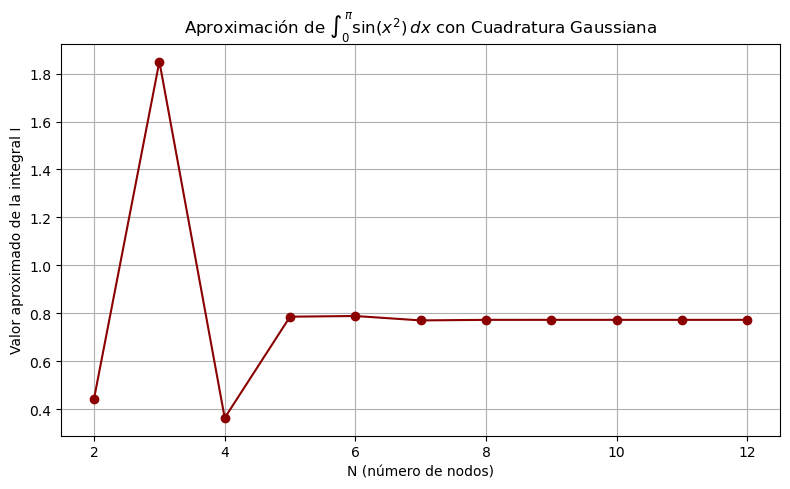

In [20]:
#Grafica


import matplotlib.pyplot as plt
import numpy as np

# Definimos la función a integrar
def f(x):
    return np.sin(x**2)

# Lista de nodos y pesos escalados ya calculados
x_list = [x1_esc, x2_esc, x3_esc, x4_esc, x5_esc, x6_esc, x7_esc, x8_esc, x9_esc, x10_esc, x11_esc]
w_list = [w1_esc, w2_esc, w3_esc, w4_esc, w5_esc, w6_esc, w7_esc, w8_esc, w9_esc, w10_esc, w11_esc]

N_values = list(range(2, 13))  # N = 2 a 12
I_values = [np.sum(w * f(x)) for x, w in zip(x_list, w_list)]

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(N_values, I_values, marker='o', linestyle='-', color='darkred')
plt.title(r"Aproximación de $\int_0^\pi \sin(x^2)\,dx$ con Cuadratura Gaussiana")
plt.xlabel("N (número de nodos)")
plt.ylabel("Valor aproximado de la integral I")
plt.grid(True)
plt.tight_layout()
plt.show()



#index.mdIntroducción al tema a resolver

Aplicar el concepto de cuadratura Gaussiana para integración utilizando 
polinomios de Legendre, para resolver la siguiente integral:
\begin{align}
\int_0^\pi \sin(x^2) {\rm{d}}x 
\end{align}

#explanation.md Introducción al problema a revolver
## Polinomios de Legendre

Los polinomios de Legendre son un sistema de polinomios ortogonales que pueden ser definidos de manera recursiva. Tenemos:
\begin{align}
\forall (M, N) \in\mathbb N^2, \quad \int_{-1}^1 {\rm{d}}x P_N(x)P_M(x) = \frac{2\delta_{MN}}{2N+1}.
\end{align}
los polinomios están definidos en el intervalo $[-1, 1]$.
Se definen empezando con
\begin{align}
P_0(x) = 1 \Rightarrow P_1(x) = x,
\end{align}
tal que los siguientes órdenes se generan con la regla de recursividad
\begin{align}
(N+1)P_{N+1}(x) = (2N+1)xP_N(x) -NP_{N-1}(x).
\end{align}
Alternativamente, los polinomios pueden ser definidos de manera iterativa bajo la regla (fórmula de Rodrigues)
\begin{align}
P_N(x) = \frac1{2^N N!}\frac{d^N}{dx^N}\left[(x^2-1)^N\right].
\end{align}

Si se quiere evaluar una integral utilizando distintos
intervalos de integración, primero se realiza el cálculo
de los puntos de muestreo $x_k$ y los pesos $w_k$ 
en el intervalo $[-1, 1]$. Esto por razones historicas se le
da este valor estandar y seguidamente, podemos escalar los
parámetros para ser modificados a un intervalo $[a, b]$ deseado.


# Cuadratura Gaussiana

Cuando ya se han calculado las posiciones y los pesos entonces, la integral esta dada por:
\begin{align}
\int_a^b {\rm{d}}x f(x) \approx \sum_{k=1}^{N} w_k f(x_k).
\end{align}
donde:
  * $w_k$ son los "pesos"
  * $x_k$ son los puntos de muestreo
  
  Para la cuadratura Gaussiana:
  * Los puntos de muestreo se escogen de manera tal que **no son equidistantes**. Esto introduce más grados de libertad para la misma discretización en $N$ subregiones.
  * Es exacta para un polinomio de orden $(2N - 1)$.

 Los pesos y puntos de muestreo se eligen tal que:
  * $x_k$ corresponden a las $N$ raíces (ceros) de los polinomios de Legendre $P_N(x)$ de orden $N$.
  * Los pesos se eligen tal que:
      - $\displaystyle w_k = \left[\frac{2}{1-x^2}\left(\frac{dP_N}{dx}\right)^{-2}\right]_{x={x_k}}$, con $x_k$ que cumple $P_N(x_k)=0$

#tutorials
```python:
import numpy as np
def gaussxw (N):
    x,w = np.polynomial.legendre.leggauss(N) 
    """""
    Calcula los nodos y pesos para la cuadratura de Gaussiana 
    en el intervalo [-1, 1].

    Parámetros:
    N: Número de nodos.

    Retorna:
    x: Arreglo de nodos.
    w: Arreglo de pesos asociados a los nodos.
    """
    
    return x, w

def gaussxwab(a, b, x, w):
    x, w = np.polynomial.legendre.leggauss(N)
    """
    Realiza el cambio de variable para transformar los nodos
    y pesos de [-1, 1] al intervalo [a, b].

    Parámetros:
    a: Límite inferior del nuevo intervalo.
    b: Límite superior del nuevo intervalo.
    x: Nodos en el intervalo [-1, 1].
    w: Pesos correspondientes en [-1, 1].

    Retorna:
    x(mapeado): Nodos transformados al intervalo [a, b].
    w_(mapeado): Pesos transformados para el intervalo [a, b].
    """


  
    
    return x, w

def gaussxwab(a, b, x, w):
   
    return 0.5 * (b - a) * x + 0.5 * (b + a), 0.5 * (b - a) * w

# Obtener nodos y pesos para distintos N
x1, w1= gaussxw(2)

#  N=3

x2, w2= gaussxw(3)

# N = 4 
x3, w3= gaussxw(4)

# Imprimir nodos y pesos en [-1, 1]

print(x1,w1)
print(x2,w2)
print(x3,w3)


# Transformar nodos y pesos en el intervalo [0, 2]
a=0
b=2
x1_esc, w1_esc = gaussxwab(a, b, x1, w1)
x2_esc, w2_esc = gaussxwab(a, b, x2, w2)
x3_esc, w3_esc = gaussxwab(a, b, x3, w3)

# Imprimir nodos y pesos escalados
print(x1_esc, w1_esc)
print(x2_esc, w2_esc)
print(x3_esc, w3_esc)

def integral(vin):
    return (vin**4) - 2*(vin**3) + 1
    """
    Función a integrar: f(x) = x^4 - 2x^3 + 1

    Parámetros:
    vin: Valor o arreglo de valores de entrada.

    Retorna:
     Resultado de aplicar la función a vin.
    """
  

    

#Calcular la integral aproximada con los nodos/pesos escalados

result_n1= np.sum(w1_esc *integral(x1_esc))
result_n2= np.sum(w2_esc *integral(x2_esc))
result_n3= np.sum(w3_esc *integral(x3_esc))

#Imprimir resultados

print(result_n1)
print(result_n2)
print(result_n3)


#reference.md
```python:
import numpy as np

def gaussxw(N):
   
    """
    Calcula los nodos y pesos para la cuadratura de Gauss-Legendre en el intervalo [-1, 1].

    Parameters
    ----------
    N : int
        Número de puntos (nodos).
   
    Returns
    -------
    x : Nodos de integración.
    w : Pesos correspondientes a los nodos.

    Ejemplo:
    --------
    >>> x, w = gaussxw(3)
    >>> x
    ([-0.77459667,  0.        ,  0.77459667])
    >>> w
    array([0.55555556, 0.88888889, 0.55555556])
    """
    return np.polynomial.legendre.leggauss(N)


def gaussxwab(a, b, x, w):
    """
    Escala los nodos y pesos desde [-1, 1] al intervalo [a, b].

    Parameters
    ----------
    a : Límite inferior del intervalo.
    b :  Límite superior del intervalo.
    x : Nodos en [-1, 1].
    w : Pesos en [-1, 1].

    Returns
    -------
    x:Nodos escalados al intervalo [a, b].
    w :Pesos escalados para el nuevo intervalo.

    Ejemplo:
    --------
    >>> x, w = gaussxw(2)
    >>> x, w = gaussxwab(0, np.pi, x, w)
    """
    return 0.5 * (b - a) * x + 0.5 * (b + a), 0.5 * (b - a) * w


def integral(vin):
    """
    Función a integrar: sin(x²)

    Parameters
    ----------
    vin : Valor de entrada.

    Returns
    -------
    
        Resultado de aplicar sin(x^2) elemento a elemento.

    Ejemplo
    --------
    >>> integral(np.pi)
    1.2246467991473532e-16
    >>> integral(np.array([0, np.sqrt(np.pi)]))
    array([0.        , 0.98776595])
    """
    return np.sin(vin**2)

